In [38]:
!pip install pydicom nibabel pylidc scikit-image pandas lxml torch torchvision torchaudio

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
import pandas as pd

df = pd.read_excel('/content/drive/MyDrive/EIS_project/excel_merged_data.xlsx')
df.head()

,Patient_ID,Total_Nodules,Nodules_>=3mm,Nodules_<3mm,"Diagnosis at the Patient Level\n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic\n",Diagnosis Method\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response,Primary tumor site for metastatic disease,"Nodule 1\nDiagnosis at the Nodule Level \n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic)\n",Nodule 1\nDiagnosis Method at the Nodule Level\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response\n,"Nodule 2\nDiagnosis at the Nodule Level \n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic)\n",Nodule 2\nDiagnosis Method at the Nodule Level\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response\n,"Nodule 3\nDiagnosis at the Nodule Level \n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic)\n",Nodule 3\nDiagnosis Method at the Nodule Level\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response\n,"Nodule 4\nDiagnosis at the Nodule Level \n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic)\n",Nodule 4\nDiagnosis Method at the Nodule Level\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response\n,"Nodule 5\nDiagnosis at the Nodule Level \n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic)\n",Nodule 5\nDiagnosis Method at the Nodule Level\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response\n
0,LIDC-IDRI-0068,7,6,1,3,4,Head & Neck Cancer,3.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LIDC-IDRI-0071,4,0,4,3,1,Head & Neck,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LIDC-IDRI-0072,3,1,2,2,4,Lung Cancer,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LIDC-IDRI-0088,6,3,3,3,0,Uterine Cancer,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LIDC-IDRI-0090,4,1,3,2,3,NSCLC,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(158, 17)
Index(['Patient_ID', 'Total_Nodules', 'Nodules_>=3mm', 'Nodules_<3mm',
       'Diagnosis at the Patient Level\n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic\n',
       'Diagnosis Method\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response',
       'Primary tumor site for metastatic disease',
       'Nodule 1\nDiagnosis at the Nodule Level \n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic)\n',
       'Nodule 1\nDiagnosis Method at the Nodule Level\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response\n',
       'Nodule 2\nDiagnosis at the Nodule Level \n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic)\n',
       'Nodule 2\

In [42]:
print(df.columns)

Index(['Patient_ID', 'Total_Nodules', 'Nodules_>=3mm', 'Nodules_<3mm',
       'Diagnosis at the Patient Level\n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic\n',
       'Diagnosis Method\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response',
       'Primary tumor site for metastatic disease',
       'Nodule 1\nDiagnosis at the Nodule Level \n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic)\n',
       'Nodule 1\nDiagnosis Method at the Nodule Level\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response\n',
       'Nodule 2\nDiagnosis at the Nodule Level \n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic)\n',
       'Nodule 2\nDiagnosis

In [43]:
target_col = 'Diagnosis at the Patient Level\n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic\n'

X = df.drop(columns=[target_col])
y = df[target_col]

In [44]:
X = X.drop(columns=['Patient_ID'])


In [45]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# Load data
df = pd.read_excel('/content/drive/MyDrive/EIS_project/excel_merged_data.xlsx')

# Target column
target_col = 'Diagnosis at the Patient Level\n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic\n'

# Split X and y
X = df.drop(columns=[target_col, 'Patient_ID'])
y = df[target_col]

# Keep only numeric features
X_numeric = X.select_dtypes(include=['number'])

# Clean data
X_numeric = X_numeric.replace([np.inf, -np.inf], np.nan)
X_numeric = X_numeric.fillna(0)
X_numeric = X_numeric.loc[:, X_numeric.std() != 0]

# Clean labels
y = y.fillna(0).astype(int)

# Normalize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

y = y.replace({0:0, 1:0, 2:1, 3:1})

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)
y_test_t = torch.tensor(y_test.values, dtype=torch.long)

# Define model
class MLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

model = MLP(X_train.shape[1])

# Train
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

for epoch in range(50):
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

# Evaluate
with torch.no_grad():
    outputs = model(X_test_t)
    _, predicted = torch.max(outputs, 1)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, predicted))

Epoch 1, Loss: 0.6669224500656128
Epoch 2, Loss: 0.662673830986023
Epoch 3, Loss: 0.6584566235542297
Epoch 4, Loss: 0.654253363609314
Epoch 5, Loss: 0.6500933766365051
Epoch 6, Loss: 0.6459558606147766
Epoch 7, Loss: 0.6418196558952332
Epoch 8, Loss: 0.6376966834068298
Epoch 9, Loss: 0.6335996389389038
Epoch 10, Loss: 0.6295284032821655
Epoch 11, Loss: 0.625487744808197
Epoch 12, Loss: 0.6214467883110046
Epoch 13, Loss: 0.6173880696296692
Epoch 14, Loss: 0.6133244037628174
Epoch 15, Loss: 0.609275758266449
Epoch 16, Loss: 0.6052550673484802
Epoch 17, Loss: 0.6012559533119202
Epoch 18, Loss: 0.5973075032234192
Epoch 19, Loss: 0.5933778882026672
Epoch 20, Loss: 0.5894619822502136
Epoch 21, Loss: 0.5855580568313599
Epoch 22, Loss: 0.581687867641449
Epoch 23, Loss: 0.5778359770774841
Epoch 24, Loss: 0.5739830136299133
Epoch 25, Loss: 0.5701367259025574
Epoch 26, Loss: 0.5662932395935059
Epoch 27, Loss: 0.5624399781227112
Epoch 28, Loss: 0.5585780143737793
Epoch 29, Loss: 0.5547084212303162

In [46]:
# switch to eval mode
model.eval()

# apply dynamic quantization
quantized_model = torch.quantization.quantize_dynamic(
    model,
    {nn.Linear},
    dtype=torch.qint8
)

/tmp/ipykernel_6629/2133112526.py:5: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


In [47]:
with torch.no_grad():
    outputs = quantized_model(X_test_t)
    _, predicted = torch.max(outputs, 1)

print("Quantized Accuracy:", accuracy_score(y_test, predicted))

Quantized Accuracy: 0.9375


In [48]:
# save model
torch.save(quantized_model.state_dict(), '/content/drive/MyDrive/EIS_project/quantized_model.pth')

In [49]:
# recreate original model
model = MLP(X_train.shape[1])

# apply quantization again
model = torch.quantization.quantize_dynamic(
    model, {nn.Linear}, dtype=torch.qint8
)

# now load weights
model.load_state_dict(torch.load('/content/drive/MyDrive/EIS_project/quantized_model.pth'))

model.eval()

/tmp/ipykernel_6629/2616052370.py:5: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model = torch.quantization.quantize_dynamic(


MLP(
  (fc1): DynamicQuantizedLinear(in_features=8, out_features=64, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (fc2): DynamicQuantizedLinear(in_features=64, out_features=32, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (fc3): DynamicQuantizedLinear(in_features=32, out_features=2, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  (relu): ReLU()
)

In [75]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score

class DeepMLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.net(x)

model_mlp = DeepMLP(X_train.shape[1])

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=0.0005)

# 🔥 ADD THESE LISTS
train_acc = []
val_acc = []

for epoch in range(50):

    # ---- TRAIN ----
    model_mlp.train()
    optimizer.zero_grad()

    outputs = model_mlp(X_train_t)
    loss = criterion(outputs, y_train_t)

    loss.backward()
    optimizer.step()

    # Calculate train accuracy
    train_pred = torch.argmax(outputs, 1)
    train_accuracy = accuracy_score(y_train, train_pred)
    train_acc.append(train_accuracy)

    # ---- VALIDATION ----
    model_mlp.eval()
    with torch.no_grad():
        val_outputs = model_mlp(X_test_t)
        val_pred = torch.argmax(val_outputs, 1)
        val_accuracy = accuracy_score(y_test, val_pred)
        val_acc.append(val_accuracy)

    print(f"Epoch {epoch+1}: Train={train_accuracy:.4f}, Val={val_accuracy:.4f}")

# Final accuracy
print("Final Test Accuracy:", val_acc[-1])

Epoch 1: Train=0.6667, Val=0.4062
Epoch 2: Train=0.6984, Val=0.4375
Epoch 3: Train=0.7222, Val=0.5000
Epoch 4: Train=0.7619, Val=0.5625
Epoch 5: Train=0.7937, Val=0.7812
Epoch 6: Train=0.7778, Val=0.8438
Epoch 7: Train=0.8016, Val=0.8438
Epoch 8: Train=0.7937, Val=0.8750
Epoch 9: Train=0.8651, Val=0.8750
Epoch 10: Train=0.8254, Val=0.8750
Epoch 11: Train=0.8333, Val=0.9375
Epoch 12: Train=0.8571, Val=0.9375
Epoch 13: Train=0.8413, Val=0.9375
Epoch 14: Train=0.8810, Val=0.9375
Epoch 15: Train=0.8651, Val=0.9375
Epoch 16: Train=0.8889, Val=0.9375
Epoch 17: Train=0.8810, Val=0.9375
Epoch 18: Train=0.8651, Val=0.9062
Epoch 19: Train=0.8810, Val=0.9062
Epoch 20: Train=0.8730, Val=0.9062
Epoch 21: Train=0.9048, Val=0.9062
Epoch 22: Train=0.8730, Val=0.9062
Epoch 23: Train=0.9048, Val=0.9062
Epoch 24: Train=0.8968, Val=0.9062
Epoch 25: Train=0.8968, Val=0.9062
Epoch 26: Train=0.8730, Val=0.9062
Epoch 27: Train=0.8968, Val=0.9062
Epoch 28: Train=0.8889, Val=0.9062
Epoch 29: Train=0.8968, Val=0

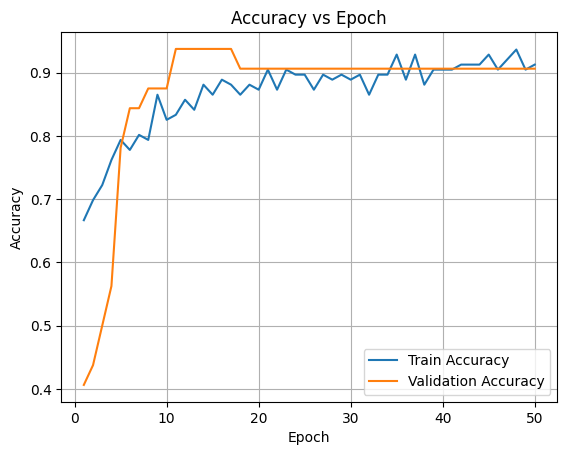

In [77]:
import matplotlib.pyplot as plt

epochs = range(1, 51)

plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.grid()
plt.show()

In [78]:
!pip install pytorch-tabnet

In [79]:
from pytorch_tabnet.tab_model import TabNetClassifier

tabnet = TabNetClassifier(verbose=0)

tabnet.fit(X_train, y_train, max_epochs=50)

pred = tabnet.predict(X_test)

acc_tabnet = accuracy_score(y_test, pred)
print("TabNet Accuracy:", acc_tabnet)

TabNet Accuracy: 0.40625


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


In [80]:
class CNN1D(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3)
        self.pool = nn.MaxPool1d(2)
        self.fc1 = nn.Linear((input_size-2)//2 * 16, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

In [81]:
model_cnn = CNN1D(X_train.shape[1])

optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.0005)

for epoch in range(50):
    optimizer.zero_grad()
    outputs = model_cnn(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

In [82]:
with torch.no_grad():
    pred = torch.argmax(model_cnn(X_test_t), 1)

acc_cnn = accuracy_score(y_test, pred)
print("CNN1D Accuracy:", acc_cnn)

CNN1D Accuracy: 0.90625


In [83]:
results = {
    "Your MLP": 0.90625,  # your previous result
    "Deep MLP": acc_mlp,
    "TabNet": acc_tabnet,
    "CNN1D": acc_cnn
}

for k, v in results.items():
    print(f"{k}: {v:.4f}")

Your MLP: 0.9062
Deep MLP: 0.9062
TabNet: 0.4062
CNN1D: 0.9062


In [84]:
model_mlp.eval()

DeepMLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=2, bias=True)
  )
)

In [85]:
import torch.nn as nn

quantized_model = torch.quantization.quantize_dynamic(
    model_mlp,
    {nn.Linear},
    dtype=torch.qint8
)

/tmp/ipykernel_6629/3260849814.py:3: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


In [90]:
# ---- AFTER TRAINING ----

model_mlp.eval()

# Quantize
quantized_model = torch.quantization.quantize_dynamic(
    model_mlp, {torch.nn.Linear}, dtype=torch.qint8
)

quantized_model.eval()

# Dummy input
input_tensor = torch.randn(1, 8)

# Warm-up
for _ in range(100):
    model_mlp(input_tensor)
    quantized_model(input_tensor)

# Measure
import time

def measure(model):
    start = time.time()
    for _ in range(1000):
        model(input_tensor)
    return (time.time() - start) / 1000

time_fp32 = measure(model_mlp)
time_int8 = measure(quantized_model)

print("Before:", time_fp32)
print("After:", time_int8)


/tmp/ipykernel_6629/2958680615.py:6: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


Before: 0.0003735654354095459
After: 0.0007903227806091308


In [91]:
with torch.no_grad():
    pred = torch.argmax(quantized_model(X_test_t), 1)

from sklearn.metrics import accuracy_score
quant_acc = accuracy_score(y_test, pred)

print("Quantized Deep MLP Accuracy:", quant_acc)

Quantized Deep MLP Accuracy: 0.90625


In [92]:
import os

# save original
torch.save(model_mlp.state_dict(), "mlp.pth")

# save quantized
torch.save(quantized_model.state_dict(), "mlp_quantized.pth")

print("Original size:", os.path.getsize("mlp.pth")/1024, "KB")
print("Quantized size:", os.path.getsize("mlp_quantized.pth")/1024, "KB")

Original size: 53.2626953125 KB
Quantized size: 23.8330078125 KB


/tmp/ipykernel_6629/2938074915.py:16: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


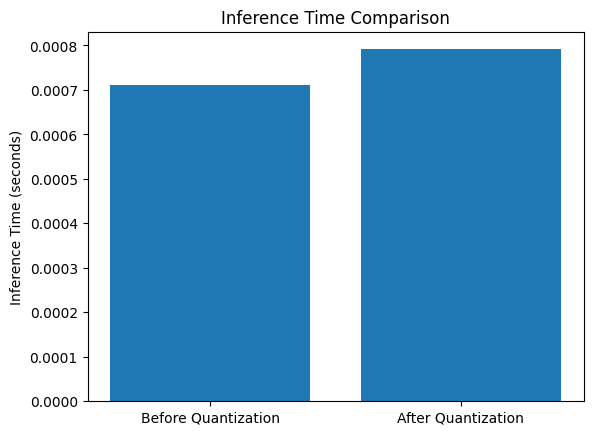

Before Quantization: 0.0007103996276855469
After Quantization: 0.000791245698928833


In [93]:
import time
import torch
import numpy as np

# Dummy input (replace with your feature size)
input_tensor = torch.randn(1, 8)

# Before quantization
start = time.time()
for _ in range(1000):
    _ = model(input_tensor)
end = time.time()
time_fp32 = (end - start) / 1000

# Apply dynamic quantization
quantized_model = torch.quantization.quantize_dynamic(
    model, {torch.nn.Linear}, dtype=torch.qint8
)

# After quantization
start = time.time()
for _ in range(1000):
    _ = quantized_model(input_tensor)
end = time.time()
time_int8 = (end - start) / 1000

# Plot
plt.figure()
plt.bar(['Before Quantization', 'After Quantization'], [time_fp32, time_int8])
plt.ylabel('Inference Time (seconds)')
plt.title('Inference Time Comparison')
plt.show()

print("Before Quantization:", time_fp32)
print("After Quantization:", time_int8)

Original size: 53.2626953125 KB
Quantized size: 23.8330078125 KB


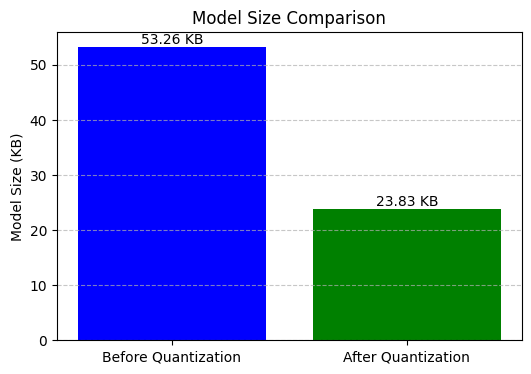

In [106]:
import torch
import os
import matplotlib.pyplot as plt

# ---- SAVE MODELS ----
torch.save(model_mlp.state_dict(), "mlp.pth")
torch.save(quantized_model.state_dict(), "mlp_quantized.pth")

# ---- GET SIZES ----
size_fp32 = os.path.getsize("mlp.pth") / 1024   # KB
size_int8 = os.path.getsize("mlp_quantized.pth") / 1024  # KB

print("Original size:", size_fp32, "KB")
print("Quantized size:", size_int8, "KB")

# ---- PLOT GRAPH ----
plt.figure(figsize=(6,4))

labels = ['Before Quantization', 'After Quantization']
sizes = [size_fp32, size_int8]

bars = plt.bar(labels, sizes, color=['blue', 'green'])

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.2f} KB',
             ha='center', va='bottom')

plt.ylabel('Model Size (KB)')
plt.title('Model Size Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [94]:
torch.save(quantized_model.state_dict(),
           '/content/drive/MyDrive/EIS_project/deep_mlp_quantized.pth')

In [95]:
model = DeepMLP(X_train.shape[1])

model = torch.quantization.quantize_dynamic(
    model, {nn.Linear}, dtype=torch.qint8
)

model.load_state_dict(torch.load('/content/drive/MyDrive/EIS_project/deep_mlp_quantized.pth'))

model.eval()

/tmp/ipykernel_6629/4069641599.py:3: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model = torch.quantization.quantize_dynamic(


DeepMLP(
  (net): Sequential(
    (0): DynamicQuantizedLinear(in_features=8, out_features=128, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): DynamicQuantizedLinear(in_features=128, out_features=64, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): DynamicQuantizedLinear(in_features=64, out_features=32, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
    (9): ReLU()
    (10): DynamicQuantizedLinear(in_features=32, out_features=2, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
  )
)

In [96]:
scripted_model = torch.jit.script(quantized_model)
scripted_model.save("deep_mlp_quantized_scripted.pt")

In [97]:
scripted_model = torch.jit.script(quantized_model)
scripted_model.save('/content/drive/MyDrive/EIS_project/deep_mlp_mobile.pt')

In [98]:
import joblib

joblib.dump(scaler, '/content/drive/MyDrive/EIS_project/scaler.save')

['/content/drive/MyDrive/EIS_project/scaler.save']

In [99]:
print(scaler.mean_)
print(scaler.scale_)

[5.48734177 2.50632911 2.98101266 1.92405063 1.34810127 1.55696203
 0.18987342 0.26582278]
[5.8663785  2.5821854  4.336293   1.24037716 1.17961169 1.50313458
 0.6764754  0.94412052]


In [100]:
print(scaler.mean_)
print(scaler.scale_)

[5.48734177 2.50632911 2.98101266 1.92405063 1.34810127 1.55696203
 0.18987342 0.26582278]
[5.8663785  2.5821854  4.336293   1.24037716 1.17961169 1.50313458
 0.6764754  0.94412052]


In [101]:
import numpy as np

x = np.array([[5.5,2.5,3.0,1.9,1.3,1.5,0.18,0.26]])
x = scaler.transform(x)

model.eval()
with torch.no_grad():
    out = model(torch.tensor(x, dtype=torch.float32))
    print(out)

tensor([[-0.4262,  0.0017]])


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [102]:
print(X.columns)

Index(['Total_Nodules', 'Nodules_>=3mm', 'Nodules_<3mm',
       'Diagnosis Method\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response',
       'Primary tumor site for metastatic disease',
       'Nodule 1\nDiagnosis at the Nodule Level \n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic)\n',
       'Nodule 1\nDiagnosis Method at the Nodule Level\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response\n',
       'Nodule 2\nDiagnosis at the Nodule Level \n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic)\n',
       'Nodule 2\nDiagnosis Method at the Nodule Level\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or

In [103]:
print(X.columns.tolist())

['Total_Nodules', 'Nodules_>=3mm', 'Nodules_<3mm', 'Diagnosis Method\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response', 'Primary tumor site for metastatic disease', 'Nodule 1\nDiagnosis at the Nodule Level \n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic)\n', 'Nodule 1\nDiagnosis Method at the Nodule Level\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response\n', 'Nodule 2\nDiagnosis at the Nodule Level \n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic)\n', 'Nodule 2\nDiagnosis Method at the Nodule Level\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response\n', 'Nodule 3\nDiagnosis at the Nodule

In [104]:
print(X.head())
print(X.columns)

   Total_Nodules  Nodules_>=3mm  Nodules_<3mm  \
0              7              6             1   
1              4              0             4   
2              3              1             2   
3              6              3             3   
4              4              1             3   

   Diagnosis Method\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response  \
0                                                  4                                                                                                                    
1                                                  1                                                                                                                    
2                                                  4                                                                                                                    
3                            